# EmbAlign Figure 1:
This notebook contains the necessary code to regenerate figure 1 in th EmbAlign manuscript. 

In [7]:
import os
import joblib
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LightSource
from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix

# Core EmbAlign components
from aligner.config import PipelineConfig
from aligner.engine import ModularAlignmentEngine
from aligner.models import EmbryoFrame, ReferenceFrame
from aligner.atlas import GPToStaticAdapter
from aligner.matcher import SinkhornMatcher, HungarianMatcher
from aligner.transformer import RigidTransformer
from aligner.oracle import DiagnosticLayer

## Load Data

In [ ]:
# Unaligned nuclei centroids
pts = pd.read_csv("data/final_registered_all_pts.csv")

# Frame level alignment results
frame_res = pd.read_csv("data/aligned_frame_results_cv.csv")

# Cell level alignment results
cell_res = pd.read_csv("data/aligned_cell_results_cv.csv")

# OOS frame level alignment results
oos_frame_res = pd.read_csv("data/oos_aligned_frame_results.csv")





In [9]:
#Font size settings
small_font = 8
med_font = 10
big_font = 12

# plot params
plt.rcParams['figure.dpi'] = 100       # Keep preview DPI lower for speed/alignment
plt.rcParams['savefig.dpi'] = 300      # Keep export DPI high for the poster
plt.rcParams['figure.autolayout'] = False # Disable auto-adjustments

# Ensure the figure size is strictly followed (prevents 'tight' cropping from changing dimensions)
plt.rcParams['savefig.bbox'] = 'standard'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

## Single Frame Alignment 

In [10]:
# Configure pipeline
config = PipelineConfig.v3_0_production()

# Load atlases
MODEL_DIR = 'production_models'
spatial_atlas = joblib.load(os.path.join(MODEL_DIR, 'master_gp_atlas.pkl'))
slice_db = joblib.load(os.path.join(MODEL_DIR, 'master_slice_db.pkl'))

# Initialize engine
engine = ModularAlignmentEngine(
    config=config,
    atlas=spatial_atlas,
    slice_db=slice_db,
    coarse_matcher=HungarianMatcher(tau=config.tau), 
    icp_matcher=SinkhornMatcher(epsilon=config.epsilon_refine),
    transformer=RigidTransformer()
)

In [11]:
# Select target frame
eid = 'nih_diSPIM_3'
t = 61
frame = EmbryoFrame.from_dataframe(pts, eid, t)
frame.prepare()

# Run traced alignment
best_result, landscape = engine.align_frame(frame, trace=True, return_diagnostics=False)

# Extract the winning reference frame
target_slice_id = best_result['slice_id'] 
state = engine.hybrid_atlas.get_temporal_state(target_slice_id, time_offset=0.5)
adapter = GPToStaticAdapter(state['labels'], state['means'], state['variances'])
ref_frame = ReferenceFrame(state['labels'], adapter)

## Figure 1A EmbAlign Schematic

### Panel 1: Input Centroids and Candidate Slices

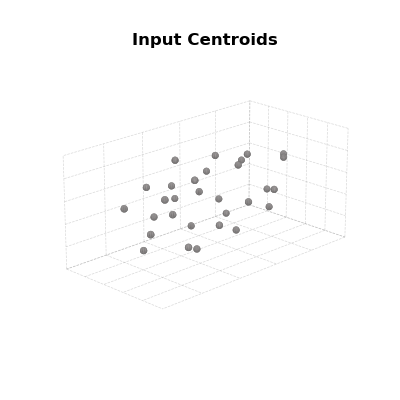

In [12]:
# Input Centroids
def plot_pipeline_input_centroids(coords):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    
    # Standardized camera angle for all schematic panels
    ELEV, AZIM = 20, 45
    
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    margin = 0.2
    x_min, x_max = x.min() - margin, x.max() + margin
    y_min, y_max = y.min() - margin, y.max() + margin
    z_min, z_max = z.min() - margin, z.max() + margin
    dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

    # Lighting and styling
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)
    sphere_color = "#A19D9D"
    radius = min(dx, dy, dz) * 0.03 
    
    # Sphere mesh generation
    u, v = np.linspace(0, 2 * np.pi, 12), np.linspace(0, np.pi, 12)
    xs_base = radius * np.outer(np.cos(u), np.sin(v))
    ys_base = radius * np.outer(np.sin(u), np.sin(v))
    zs_base = radius * np.outer(np.ones(np.size(u)), np.cos(v))

    # Stage setup
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((dx, dy, dz)) 
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.dist = 11 

    # Render bounding grid walls
    grid_params = dict(color='gray', linestyle='--', alpha=0.3, lw=0.5)
    ticks = 6
    for val in np.linspace(x_min, x_max, ticks):
        ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
        ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
    for val in np.linspace(y_min, y_max, ticks):
        ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
        ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
    for val in np.linspace(z_min, z_max, ticks):
        ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
        ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)

    ax.set_axis_off()
    ax.set_title("Input Centroids", fontsize=big_font, pad=-5, fontweight='bold')

    # Render Opaque Spheres
    z_lift = dz * 0.02
    for i in range(len(coords)):
        ax.plot_surface(
            xs_base + x[i], ys_base + y[i], zs_base + z[i] + z_lift,
            color=sphere_color, rstride=1, cstride=1, antialiased=True,
            shade=True, lightsource=ls, linewidth=0
        )
    plt.savefig('fig_outs/input_centroids.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

plot_pipeline_input_centroids(frame.normalized_coords)

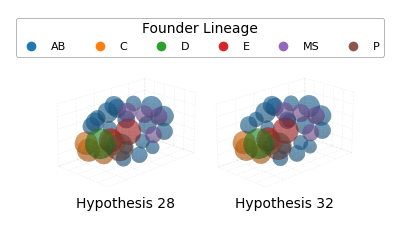

In [13]:
# Candidate Slices
def plot_candidate_atlas_row(candidate_ids, hybrid_atlas, max_cols=3):
    """
    Iterates through candidates, builds ReferenceFrames, and plots them in a row.
    Names are at the bottom, legend is at the top.
    """
    # Limit the number of candidates plotted so the schematic doesn't get too wide
    plot_ids = candidate_ids[:max_cols]
    n_candidates = len(plot_ids)
    
    fig = plt.figure(figsize=(2.0 * n_candidates, 2.5))
    ELEV, AZIM = 20, 45
    
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)
    grid_params = dict(color='gray', linestyle='--', alpha=0.1, lw=0.5)
    ticks = 6
    scale_factor = 2.5 
    u, v = np.linspace(0, 2 * np.pi, 12), np.linspace(0, np.pi, 12)
    
    def get_lineage(name):
        match = re.match(r'^([A-Z]+)', name)
        return match.group(1) if match else 'Other'

    # 1. Build the Reference Frames
    frames = []
    all_labels = []
    for c_id in plot_ids:
        state = hybrid_atlas.get_temporal_state(c_id, time_offset=0.5)
        adapter = GPToStaticAdapter(state['labels'], state['means'], state['variances'])
        ref_frame = ReferenceFrame(state['labels'], adapter)
        frames.append(ref_frame)
        all_labels.extend(state['labels'])
        
    unique_lineages = sorted(list(set(get_lineage(l) for l in all_labels)))
    palette = sns.color_palette("tab10", len(unique_lineages))
    lineage_colors = {lin: palette[i] for i, lin in enumerate(unique_lineages)}

    # 2. Plot Each Candidate in a Subplot
    for idx, ref_frame in enumerate(frames):
        ax = fig.add_subplot(1, n_candidates, idx + 1, projection='3d')
        
        # Zero-center the means dynamically for the visual stage
        coords = ref_frame.means - ref_frame.center_of_mass
        labels = ref_frame.labels
        variances = np.array([np.diag(c) for c in ref_frame.covs])
        
        margin = 0.2
        x_min, x_max = coords[:, 0].min() - margin, coords[:, 0].max() + margin
        y_min, y_max = coords[:, 1].min() - margin, coords[:, 1].max() + margin
        z_min, z_max = coords[:, 2].min() - margin, coords[:, 2].max() + margin
        dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_zlim(z_min, z_max)
        ax.set_box_aspect((dx, dy, dz))
        ax.view_init(elev=ELEV, azim=AZIM)
        ax.dist = 11

        for val in np.linspace(x_min, x_max, ticks):
            ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
            ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
        for val in np.linspace(y_min, y_max, ticks):
            ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
            ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
        for val in np.linspace(z_min, z_max, ticks):
            ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
            ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)
        
        ax.set_axis_off()
        
        # Candidate Names at the Bottom
        ax.text2D(0.5, -0.01, f"Hypothesis {plot_ids[idx]}", transform=ax.transAxes, 
                  ha='center', fontsize=med_font)

        # Render the lineage-colored ellipsoids
        for i in range(len(coords)):
            r = np.sqrt(np.mean(variances[i])) * scale_factor
            lin = get_lineage(labels[i])
            xs = r * np.outer(np.cos(u), np.sin(v)) + coords[i, 0]
            ys = r * np.outer(np.sin(u), np.sin(v)) + coords[i, 1]
            zs = r * np.outer(np.ones(np.size(u)), np.cos(v)) + coords[i, 2]
            ax.plot_surface(xs, ys, zs, color=lineage_colors[lin],
                            alpha=0.4, antialiased=True, shade=True,
                            lightsource=ls, linewidth=0)

    # 3. Unified Legend at the Top
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=lin,
               markerfacecolor=lineage_colors[lin], markersize=8)
        for lin in unique_lineages
    ]
    
    fig.legend(
        handles=legend_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 0.95), 
        ncol=len(unique_lineages), 
        fontsize=small_font, 
        title="Founder Lineage", 
        title_fontsize=med_font,
        frameon=True, 
        edgecolor='gray'
    ).get_frame().set_linewidth(0.5)

    plt.subplots_adjust(top=0.8, bottom=0.15, wspace=0.05)
    plt.savefig('fig_outs/slice_candidates.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

candidate_ids = engine.slice_db.get_candidates(len(frame))
plot_candidate_atlas_row(candidate_ids, engine.hybrid_atlas, max_cols=2)

### Panel 2: Coarse Roll Scan

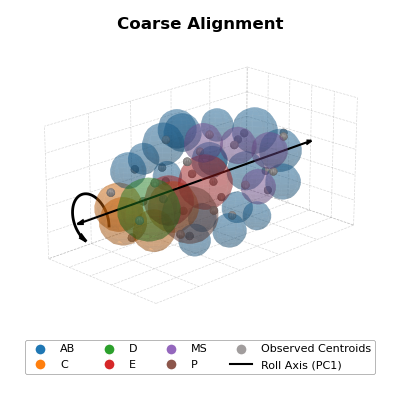

In [14]:
# Coarse Roll Schematic
def plot_coarse_roll_scan_schematic_final(observed_coords, ref_frame):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_position([0.05, 0.12, 0.9, 0.85])
    
    ELEV, AZIM = 20, 45
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)
    grid_params = dict(color='gray', linestyle='--', alpha=0.3, lw=0.5)
    ticks = 6
    u, v = np.linspace(0, 2 * np.pi, 12), np.linspace(0, np.pi, 12)
    
    observed_color = "#A19D9D"

    # 1. Data Extraction (REFACTORED for V3)
    atlas_coords = ref_frame.means - ref_frame.center_of_mass
    labels = ref_frame.labels
    variances = np.array([np.diag(c) for c in ref_frame.covs])
    pc1_vec = ref_frame.pc1_axis 
    
    def get_lineage(name):
        match = re.match(r'^([A-Z]+)', name)
        return match.group(1) if match else 'Other'

    lineage_list = [get_lineage(l) for l in labels]
    unique_lineages = sorted(list(set(lineage_list)))
    palette = sns.color_palette("tab10", len(unique_lineages))
    lineage_colors = {lin: palette[i] for i, lin in enumerate(unique_lineages)}

    all_pts = np.vstack([atlas_coords, observed_coords])
    margin = 0.2
    x_min, x_max = all_pts[:, 0].min() - margin, all_pts[:, 0].max() + margin
    y_min, y_max = all_pts[:, 1].min() - margin, all_pts[:, 1].max() + margin
    z_min, z_max = all_pts[:, 2].min() - margin, all_pts[:, 2].max() + margin
    dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((dx, dy, dz))
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.dist = 9 

    for val in np.linspace(x_min, x_max, ticks):
        ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
        ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
    for val in np.linspace(y_min, y_max, ticks):
        ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
        ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
    for val in np.linspace(z_min, z_max, ticks):
        ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
        ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)
    ax.set_axis_off()

    scale_factor = 2.5 
    for i in range(len(atlas_coords)):
        r = np.sqrt(np.mean(variances[i])) * scale_factor
        xs, ys, zs = r * np.outer(np.cos(u), np.sin(v)) + atlas_coords[i, 0], r * np.outer(np.sin(u), np.sin(v)) + atlas_coords[i, 1], r * np.outer(np.ones(np.size(u)), np.cos(v)) + atlas_coords[i, 2]
        ax.plot_surface(xs, ys, zs, color=lineage_colors[lineage_list[i]], alpha=0.3, linewidth=0, shade=True, lightsource=ls)

    obs_r = min(dx, dy, dz) * 0.03
    for i in range(len(observed_coords)):
        xs_o, ys_o, zs_o = obs_r * np.outer(np.cos(u), np.sin(v)) + observed_coords[i, 0], obs_r * np.outer(np.sin(u), np.sin(v)) + observed_coords[i, 1], obs_r * np.outer(np.ones(np.size(u)), np.cos(v)) + observed_coords[i, 2]
        ax.plot_surface(xs_o, ys_o, zs_o, color=observed_color, alpha=1.0, linewidth=0, shade=True, lightsource=ls)

    origin_ref = np.array([0, 0, 0])
    arrow_len = dx * 0.6
    for d in [1, -1]:
        ax.quiver(0, 0, 0, d*pc1_vec[0], d*pc1_vec[1], d*pc1_vec[2], length=arrow_len, color='black', lw=1.5, arrow_length_ratio=0.05)

    gizmo_anchor = origin_ref + pc1_vec * (arrow_len * 0.9)
    theta = np.linspace(0, 1.4 * np.pi, 50) 
    radius_ring = min(dx, dy, dz) * 0.18
    
    ring_pts_base = np.zeros((len(theta), 3))
    ring_pts_base[:, 1], ring_pts_base[:, 2] = radius_ring * np.cos(theta), radius_ring * np.sin(theta)
    
    v_cross = np.cross([1, 0, 0], pc1_vec)
    c_dot = np.dot([1, 0, 0], pc1_vec)
    if np.abs(c_dot + 1) > 1e-6:
        s_sin = np.linalg.norm(v_cross)
        kmat = np.array([[0, -v_cross[2], v_cross[1]], [v_cross[2], 0, -v_cross[0]], [-v_cross[1], v_cross[0], 0]])
        rot_matrix = np.eye(3) + kmat + kmat.dot(kmat) * ((1 - c_dot) / (s_sin**2))
        ring_pts_final = ring_pts_base.dot(rot_matrix.T) + gizmo_anchor
    else:
        ring_pts_final = ring_pts_base + gizmo_anchor

    ax.plot(ring_pts_final[:, 0], ring_pts_final[:, 1], ring_pts_final[:, 2], color='black', lw=2)
    
    tip = ring_pts_final[-1]
    tangent = ring_pts_final[-1] - ring_pts_final[-3] 
    tangent /= np.linalg.norm(tangent)
    
    ax.quiver(tip[0], tip[1], tip[2], 
              tangent[0], tangent[1], tangent[2], 
              length=arrow_len * 0.05, 
              color='black', 
              pivot='tip', 
              arrow_length_ratio=1, 
              lw=2, 
              zorder=100) 

    legend_elements = [Line2D([0], [0], marker='o', color='w', label=lin, markerfacecolor=lineage_colors[lin], markersize=8) for lin in unique_lineages]
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Observed Centroids', markerfacecolor=observed_color, markersize=8))
    legend_elements.append(Line2D([0], [0], color='black', lw=1.5, label='Roll Axis (PC1)'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=4, fontsize=small_font, frameon=True, edgecolor='gray').get_frame().set_linewidth(0.5)

    plt.title("Coarse Alignment", fontsize=big_font, pad=-15, fontweight='bold', y= 1.1)
    plt.savefig('fig_outs/coarse_schematic.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

plot_coarse_roll_scan_schematic_final(frame.normalized_coords, ref_frame)

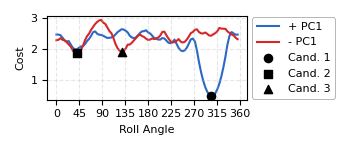

In [15]:
# Coarse Roll Cost Landscape

# Extract coarse roll landscape data
coarse_data = landscape[target_slice_id]['coarse']

sign_pos = [d for d in coarse_data if d['sign'] == 1.0]
sign_neg = [d for d in coarse_data if d['sign'] == -1.0]

angles_pos, costs_pos = [d['angle'] for d in sign_pos], [d['cost'] for d in sign_pos]
angles_neg, costs_neg = [d['angle'] for d in sign_neg], [d['cost'] for d in sign_neg]
local_minima = []
for sign_trace in [sign_pos, sign_neg]:
    trace = sorted(sign_trace, key=lambda x: x['angle'])
    N = len(trace)
    for i in range(N):
        if trace[i]['cost'] < trace[(i-1)%N]['cost'] and trace[i]['cost'] < trace[(i+1)%N]['cost']:
            local_minima.append(trace[i])

sorted_minima = sorted(local_minima, key=lambda x: x['cost'])

# Apply the 30-degree exclusion zone
top_candidates = []
for entry in sorted_minima:
    is_new = True
    for v in top_candidates:
        if entry['sign'] == v['sign']:
            diff = abs(entry['angle'] - v['angle'])
            if min(diff, 360 - diff) < 30:
                is_new = False
                break
    if is_new:
        top_candidates.append(entry)
    if len(top_candidates) >= 3: 
        break

plt.figure(figsize=(3.5, 1.5)) 

plt.plot(angles_pos, costs_pos, label='+ PC1', color='#2D68C4', lw=1.5, zorder=1)
plt.plot(angles_neg, costs_neg, label='- PC1', color='#d62728', lw=1.5, zorder=1)

markers = ['o', 's', '^']
for idx, cand in enumerate(top_candidates):
    plt.scatter(cand['angle'], cand['cost'], color='black', marker=markers[idx], 
                s=35, zorder=5, label=f"Cand. {idx+1}")

# Styling
plt.grid(linestyle='--', alpha=0.3)
plt.xlabel("Roll Angle", fontsize=8)
plt.ylabel("Cost", fontsize=small_font)
plt.xticks(np.arange(0, 361, 45), fontsize=small_font)
plt.yticks(fontsize=small_font)
plt.legend(fontsize=small_font, frameon=True, edgecolor='gray',loc='center left', bbox_to_anchor=(1, 0.5)).get_frame().set_linewidth(0.5)
plt.tight_layout()
plt.savefig('fig_outs/coarse_landscape.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

### Panel 3: Sinkhorn Refinement

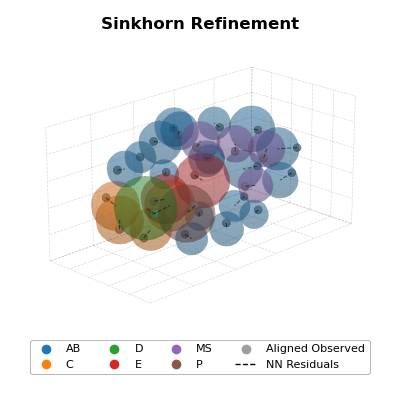

In [16]:
# Sinkhorn Refinement Schematic
def plot_icp_refinement_with_nearest_residuals(aligned_coords, ref_frame):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_position([0.05, 0.12, 0.9, 0.85])
    
    ELEV, AZIM = 20, 45
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)
    grid_params = dict(color='gray', linestyle='--', alpha=0.3, lw=0.5)
    ticks = 6
    u, v = np.linspace(0, 2 * np.pi, 15), np.linspace(0, np.pi, 15)
    
    aligned_obs_color = "#A19D9D" # Consistent opaque grey

    # 1. Data Extraction 
    atlas_coords = ref_frame.means - ref_frame.center_of_mass
    shifted_aligned_coords = aligned_coords - ref_frame.center_of_mass
    
    labels = ref_frame.labels
    variances = np.array([np.diag(c) for c in ref_frame.covs])
    
    # 2. Lineage Color Mapping
    def get_lineage(name):
        match = re.match(r'^([A-Z]+)', name)
        return match.group(1) if match else 'Other'

    lineage_list = [get_lineage(l) for l in labels]
    unique_lineages = sorted(list(set(lineage_list)))
    palette = sns.color_palette("tab10", len(unique_lineages))
    lineage_colors = {lin: palette[i] for i, lin in enumerate(unique_lineages)}

    # 3. Coordinate Bounds
    all_pts = np.vstack([atlas_coords, shifted_aligned_coords])
    margin = 0.2
    x_min, x_max = all_pts[:, 0].min() - margin, all_pts[:, 0].max() + margin
    y_min, y_max = all_pts[:, 1].min() - margin, all_pts[:, 1].max() + margin
    z_min, z_max = all_pts[:, 2].min() - margin, all_pts[:, 2].max() + margin
    dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

    # 4. Stage Setup
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((dx, dy, dz))
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.dist = 9 

    for val in np.linspace(x_min, x_max, ticks):
        ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
        ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
    for val in np.linspace(y_min, y_max, ticks):
        ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
        ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
    for val in np.linspace(z_min, z_max, ticks):
        ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
        ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)
    ax.set_axis_off()

    # 5. Render Entities
    scale_factor = 2.5 
    for i in range(len(atlas_coords)):
        r = np.sqrt(np.mean(variances[i])) * scale_factor
        xs, ys, zs = r * np.outer(np.cos(u), np.sin(v)) + atlas_coords[i, 0], r * np.outer(np.sin(u), np.sin(v)) + atlas_coords[i, 1], r * np.outer(np.ones(np.size(u)), np.cos(v)) + atlas_coords[i, 2]
        ax.plot_surface(xs, ys, zs, color=lineage_colors[lineage_list[i]], alpha=0.3, antialiased=True, shade=True, lightsource=ls, linewidth=0)

    obs_radius = min(dx, dy, dz) * 0.03
    for i in range(len(shifted_aligned_coords)):
        xs_o, ys_o, zs_o = obs_radius * np.outer(np.cos(u), np.sin(v)) + shifted_aligned_coords[i, 0], obs_radius * np.outer(np.sin(u), np.sin(v)) + shifted_aligned_coords[i, 1], obs_radius * np.outer(np.ones(np.size(u)), np.cos(v)) + shifted_aligned_coords[i, 2]
        ax.plot_surface(xs_o, ys_o, zs_o, color=aligned_obs_color, alpha=1.0, antialiased=True, shade=True, lightsource=ls, linewidth=0)

    # 6. Nearest Neighbor Residuals
    distances = cdist(shifted_aligned_coords, atlas_coords)
    closest_atlas_idx = np.argmin(distances, axis=1)

    for i, target_idx in enumerate(closest_atlas_idx):
        ax.plot(
            [shifted_aligned_coords[i, 0], atlas_coords[target_idx, 0]],
            [shifted_aligned_coords[i, 1], atlas_coords[target_idx, 1]],
            [shifted_aligned_coords[i, 2], atlas_coords[target_idx, 2]],
            color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=100
        )

    # 7. Legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=lin, markerfacecolor=lineage_colors[lin], markersize=8) for lin in unique_lineages]
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Aligned Observed', markerfacecolor=aligned_obs_color, markersize=8))
    legend_elements.append(Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='NN Residuals'))
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=4, fontsize=small_font, frameon=True, edgecolor='gray').get_frame().set_linewidth(0.5)

    plt.title("Sinkhorn Refinement", fontsize=big_font, pad=-15, fontweight='bold', y = 1.1)
    plt.savefig('fig_outs/sinkhorn_schematic.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

plot_icp_refinement_with_nearest_residuals(best_result['coords'], ref_frame)

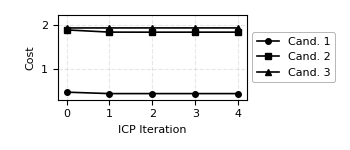

In [17]:
# Sinkhorn Refinement Convergence

def plot_tournament_icp_histories_consistent(landscape_dict, slice_id):
    # Extract the tournament outcomes for the winning slice
    tournament = landscape_dict[slice_id]['tournament']
    markers = ['o', 's', '^']
    plt.figure(figsize=(3.5, 1.5))
    all_costs = []
    for idx, candidate in enumerate(tournament[:3]):
        history = candidate['icp_history'][:5] 
        if not history:
            continue
        iters = [entry['iter'] for entry in history]
        costs = [entry['cost'] for entry in history]
        all_costs.extend(costs)
        marker_style = markers[idx]
        plt.plot(iters, costs, marker=marker_style, markersize=4, lw=1.2, 
                 color='black', markerfacecolor='black', label=f"Cand. {idx+1}")

    plt.xlabel("ICP Iteration", fontsize=small_font)
    plt.ylabel("Cost", fontsize=small_font)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xticks([0, 1, 2, 3, 4], fontsize=small_font)
    plt.yticks(fontsize=small_font)
    if all_costs:
        plt.ylim(min(all_costs) * 0.7, max(all_costs) * 1.15)
    plt.legend(fontsize=small_font, frameon=True, edgecolor='gray', 
               loc='center left', bbox_to_anchor=(1, 0.5)).get_frame().set_linewidth(0.5)
    plt.tight_layout()
    plt.savefig('fig_outs/sinkhorn_convergence.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

plot_tournament_icp_histories_consistent(landscape, target_slice_id)

### Panel 4: Label Assignment

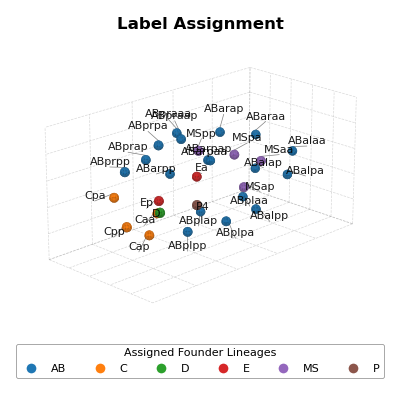

In [18]:
# Label Assignment Schematic

def repulse_labels(coords, radius, iterations=25, k=0.035):
    """
    Applies iterative repulsion to labels to minimize overlap in 3D space.
    Slightly tuned for better separation.
    """
    label_pos = coords.copy()
    label_pos[:, 2] += radius * 2.0 
    
    for _ in range(iterations):
        for i in range(len(label_pos)):
            diffs = label_pos - label_pos[i]
            dists = np.linalg.norm(diffs, axis=1, keepdims=True)
            dists[dists == 0] = 1.0 
            force = diffs / (dists**2 + 0.1)
            label_pos[i] -= np.sum(force * k, axis=0)
            drift = label_pos[i] - coords[i]
            max_drift = radius * 4.0 
            if np.linalg.norm(drift) > max_drift:
                label_pos[i] = coords[i] + (drift / np.linalg.norm(drift)) * max_drift
                
    return label_pos

def plot_label_transfer_stage(result_entry, ref_frame):
    coords = result_entry['coords'] - ref_frame.center_of_mass
    assigned_labels = result_entry['labels']
    
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_position([0.05, 0.12, 0.9, 0.85])
    
    # --- 1. Stage Styling & Lighting ---
    ELEV, AZIM = 20, 45
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)
    grid_params = dict(color='gray', linestyle='--', alpha=0.3, lw=0.5)
    u, v = np.linspace(0, 2 * np.pi, 12), np.linspace(0, np.pi, 12)
    
    # --- 2. Color Mapping ---
    def get_lineage(name):
        match = re.match(r'^([A-Z]+)', name)
        return match.group(1) if match else 'Other'

    lineage_list = [get_lineage(l) for l in assigned_labels]
    unique_lineages = sorted(list(set(lineage_list)))
    palette = sns.color_palette("tab10", len(unique_lineages))
    lineage_colors = {lin: palette[i] for i, lin in enumerate(unique_lineages)}

    # --- 3. Stage Bounds & Grid ---
    margin = 0.3
    x_min, x_max = coords[:, 0].min() - margin, coords[:, 0].max() + margin
    y_min, y_max = coords[:, 1].min() - margin, coords[:, 1].max() + margin
    z_min, z_max = coords[:, 2].min() - margin, coords[:, 2].max() + margin
    dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((dx, dy, dz))
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.dist = 9 

    # Construct the room grids
    ticks = 6
    for val in np.linspace(x_min, x_max, ticks):
        ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
        ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
    for val in np.linspace(y_min, y_max, ticks):
        ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
        ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
    for val in np.linspace(z_min, z_max, ticks):
        ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
        ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)
    ax.set_axis_off()

    # --- 4. Render Entities with Repulsion ---
    obs_radius = min(dx, dy, dz) * 0.035
    repulsed_pos = repulse_labels(coords, obs_radius)

    for i in range(len(coords)):
        # Centroid Sphere
        xs = obs_radius * np.outer(np.cos(u), np.sin(v)) + coords[i, 0]
        ys = obs_radius * np.outer(np.sin(u), np.sin(v)) + coords[i, 1]
        zs = obs_radius * np.outer(np.ones(np.size(u)), np.cos(v)) + coords[i, 2]
        
        ax.plot_surface(xs, ys, zs, color=lineage_colors[lineage_list[i]], 
                        alpha=1.0, shade=True, lightsource=ls, linewidth=0, zorder=10)

        # Floating Text Label
        ax.text(repulsed_pos[i, 0], repulsed_pos[i, 1], repulsed_pos[i, 2], 
                assigned_labels[i], fontsize=small_font,
                ha='center', va='bottom', color='black', alpha=0.9, zorder=100)
        
        # Faint leader line to anchor label to sphere
        ax.plot([coords[i, 0], repulsed_pos[i, 0]], 
                [coords[i, 1], repulsed_pos[i, 1]], 
                [coords[i, 2] + obs_radius, repulsed_pos[i, 2]], 
                color='black', lw=0.5, alpha=0.5, zorder=1)

    # --- 5. Legend Construction ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=lin,
               markerfacecolor=lineage_colors[lin], markersize=small_font)
        for lin in unique_lineages
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.04), 
               ncol=6, fontsize=small_font, title="Assigned Founder Lineages", title_fontsize=small_font,
               frameon=True, edgecolor='gray').get_frame().set_linewidth(0.6)

    plt.title("Label Assignment", fontsize=big_font, fontweight='bold', pad=-15, y=1.1)
    plt.savefig('fig_outs/label_assignment.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

plot_label_transfer_stage(best_result, ref_frame)

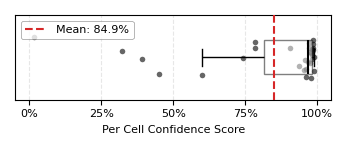

In [19]:
# Oracle Confidence Distribution
def plot_confidence_distribution_strip(diag_df, target_eid, target_t):
    # 1. Extraction
    frame_data = diag_df[
        (diag_df['embryo_id'].astype(str) == str(target_eid)) & 
        (diag_df['time_idx'].astype(int) == int(target_t))
    ]
    conf_col = 'confidence' if 'confidence' in frame_data.columns else 'confidence_score'
    confidences = frame_data[conf_col].dropna().values
    mean_conf = np.mean(confidences)

    # 2. Setup Figure
    plt.figure(figsize=(3.5, 1.5))

    # 3. Plot Horizontal Strip Plot 
    sns.stripplot(
        x=confidences, 
        color='black', 
        alpha=0.6, 
        jitter=0.25, 
        size=4,
        zorder=1
    )

    # 4. Overlay box plot
    sns.boxplot(
        x=confidences, 
        color='white', 
        width=0.4, 
        fliersize=0, 
        zorder=5, 
        boxprops=dict(alpha=0.5, edgecolor='black', linewidth=1),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1)
    )

    # 5. Add Mean Marker
    plt.axvline(mean_conf, color='#d62728', linestyle='--', linewidth=1.5, zorder=10, 
                label=f"Mean: {mean_conf*100:.1f}%")

    # 6. Formatting
    plt.grid(axis='x', linestyle='--', alpha=0.3) # Only horizontal grid lines needed here
    plt.xlabel("Per Cell Confidence Score", fontsize=small_font)
    plt.yticks([]) 
    plt.ylabel("")
    plt.xlim(-0.05, 1.05)
    plt.xticks([0.0, 0.25, 0.50, 0.75, 1.0], ['0%', '25%', '50%', '75%', '100%'], fontsize=small_font)
    plt.legend(fontsize=small_font, frameon=True, edgecolor='gray', loc='upper left').get_frame().set_linewidth(0.5)
    plt.tight_layout()
    plt.savefig('fig_outs/conf_dist.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()
    
plot_confidence_distribution_strip(cell_res, eid, t)

## Figure 1B: Accuracy vs. Canonical Time

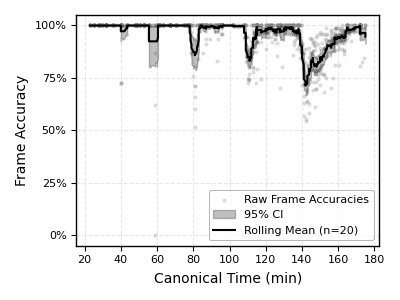

In [20]:
# Rolling Mean Accuracy Over Canonical Time

# 1. Sort the raw data chronologically
eval_df = frame_res
eval_df_sorted = eval_df.sort_values('canonical_time').copy()
y_vals = eval_df_sorted['positional_accuracy'].values
x_vals = eval_df_sorted['canonical_time'].values

window_size = 20
n_bootstraps = 500 
half_w = window_size // 2

# Calculate the rolling mean
eval_df_sorted['rolling_mean'] = eval_df_sorted['positional_accuracy'].rolling(window=window_size, center=True).mean()

# 2. Bootstrap the localized Confidence Intervals
lower_bounds = []
upper_bounds = []

for i in range(len(y_vals)):
    # Define the local window boundaries
    start = max(0, i - half_w)
    end = min(len(y_vals), i + half_w + (window_size % 2))
    window_data = y_vals[start:end]
    
    # Only bootstrap if we have enough points in the window
    if len(window_data) < (window_size * 0.5):
        lower_bounds.append(np.nan)
        upper_bounds.append(np.nan)
    else:
        # Randomly resample this specific local window 'n_bootstraps' times
        boot_samples = np.random.choice(window_data, size=(n_bootstraps, len(window_data)), replace=True)
        boot_means = np.mean(boot_samples, axis=1)
        # Extract the 95% Confidence Interval from the simulated means
        lower_bounds.append(np.percentile(boot_means, 2.5))
        upper_bounds.append(np.percentile(boot_means, 97.5))

eval_df_sorted['ci_lower'] = lower_bounds
eval_df_sorted['ci_upper'] = upper_bounds
# Drop NaN edges where the window didn't have enough data
plot_df = eval_df_sorted.dropna(subset=['rolling_mean', 'ci_lower'])

# 3. Setup Figure
fig, ax = plt.subplots(figsize=(4, 3))

# 4. Plot the raw points faintly in the background
ax.scatter(plot_df['canonical_time'], plot_df['positional_accuracy'], 
           color='gray', alpha=0.20, s=4, zorder=1, label="Raw Frame Accuracies")

# 5. Plot the strictly bounded Bootstrapped CI and the smooth rolling mean
ax.fill_between(plot_df['canonical_time'], plot_df['ci_lower'], plot_df['ci_upper'], 
                color='black', alpha=0.25, zorder=2, label="95% CI")

ax.plot(plot_df['canonical_time'], plot_df['rolling_mean'], 
        color='black', linewidth=1.5, zorder=5, label=f'Rolling Mean (n={window_size})')

# 6. Formatting & Consistency
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel("Canonical Time (min)", fontsize=med_font)
ax.set_ylabel("Frame Accuracy", fontsize=med_font)
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=small_font)
ax.tick_params(axis='x', labelsize=8)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)
ax.legend(fontsize=small_font, frameon=True, edgecolor='gray', loc='lower right').get_frame().set_linewidth(0.5)
plt.tight_layout()
plt.savefig('fig_outs/global_acc.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

## Figure 1C: OOS Accuracy vs Canonical Time

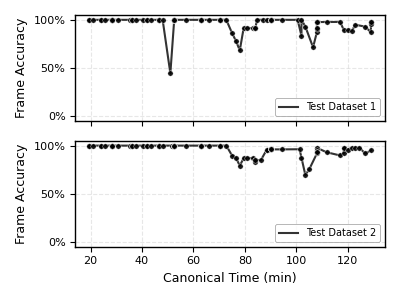

In [21]:
# OOS Accuracy

# 1. Define your two target embryos
dual_df = oos_frame_res.copy()
dual_df = dual_df.sort_values('canonical_time')
target_embryos = ['OOS_SPIMA_P4', 'OOS_SPIMA_P6'] 
display_names = {
    'OOS_SPIMA_P4': 'Test Dataset 1',
    'OOS_SPIMA_P6': 'Test Dataset 2'
}

# 2. Setup Figure (2 rows, 1 column, shared X axis)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4, 3), sharex=True)

# 3. Loop through each embryo and its assigned subplot axis
for i, (embryo_id, ax) in enumerate(zip(target_embryos, axes)):
    embryo_data = dual_df[dual_df['embryo_id'] == embryo_id]
    label_name = display_names[embryo_id]
    
    sns.lineplot(
        data=embryo_data, 
        x='canonical_time', 
        y='positional_accuracy', 
        color='black',
        estimator=None,  # No smoothing
        linewidth=1.5,
        alpha=0.8,
        ax=ax,
        label=label_name
    )

    sns.scatterplot(
        data=embryo_data, 
        x='canonical_time', 
        y='positional_accuracy', 
        color='black',
        s=15,            
        alpha=0.9,
        legend=False,    
        ax=ax,
        zorder=5
    )
    
    # 4. Formatting & Consistency
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylabel("Frame Accuracy", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0,0.50, 1.0])
    ax.set_yticklabels(['0%','50%','100%'], fontsize=8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)
    ax.legend(fontsize=7, frameon=True, edgecolor='gray', loc='lower right').get_frame().set_linewidth(0.5)

# 5. Global X-Axis Labeling
axes[-1].set_xlabel("Canonical Time (min)", fontsize=9)
axes[-1].tick_params(axis='x', labelsize=8)
plt.subplots_adjust(hspace=0.05)
plt.tight_layout()
plt.savefig('fig_outs/oos_acc.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

## Figure 1D: Poorest Performing Cell Types

/var/folders/lp/n34hrkfx4pn_kb6_zn03j75m0000gn/T/ipykernel_32490/2321891806.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=small_font)


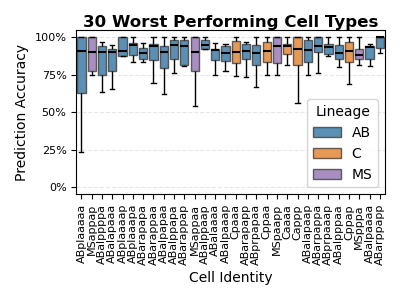

In [22]:
# 30 worst performing cells

# 1. Aggregate accuracy per cell/embryo for distribution
cell_embryo_stats = cell_res.groupby(['cell_name', 'embryo_id']).agg({
    'is_correct': 'mean',
    'lineage': 'first' 
}).reset_index()

# Sort by overall mean accuracy across all embryos to rank them
sorted_cells = cell_embryo_stats.groupby('cell_name')['is_correct'].mean().sort_values(ascending=True)
bottom_30_names = sorted_cells.index[:30] # Taking the 30 worst performing cells
subset_stats = cell_embryo_stats[cell_embryo_stats['cell_name'].isin(bottom_30_names)].copy()
tab10 = sns.color_palette("tab10")

# Map colors for consistency with rest of figure
lineage_colors = {
    'AB': tab10[0],  # Blue
    'C':  tab10[1],  # Orange
    'MS': tab10[4],  # Purple
    'E':  tab10[2],  # Green
    'D':  tab10[3],  # Red
    'P':  tab10[5],  # Brown
    'Other': tab10[7] # Gray
}

# Ensure all lineages in our subset exist in the dictionary so Seaborn doesn't crash
subset_stats['Lineage'] = subset_stats['lineage'].apply(lambda x: x if x in lineage_colors else 'Other')

# 2. Setup Figure 
fig, ax = plt.subplots(figsize=(4, 3)) 

# 3. Plot the Boxplot
sns.boxplot(
    data=subset_stats, 
    x='cell_name', 
    y='is_correct', 
    hue='Lineage', 
    order=bottom_30_names, 
    palette=lineage_colors,
    showfliers=False,
    ax=ax,
    boxprops={'linewidth': 1.0, 'alpha': 0.8},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black', 'linewidth': 1.0},
    capprops={'color': 'black', 'linewidth': 1.0}
)
ax.grid(axis='y', linestyle='--', alpha=0.3) 
ax.set_xlabel("Cell Identity", fontsize=med_font)
ax.set_ylabel("Prediction Accuracy", fontsize=med_font)
ax.set_title("30 Worst Performing Cell Types", fontsize=big_font, pad=-15,fontweight='bold') 
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0.0, 0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=small_font)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=small_font)
plt.tight_layout()
plt.savefig('fig_outs/worst_performing.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

## Figure 1E: Precision Recall Curve

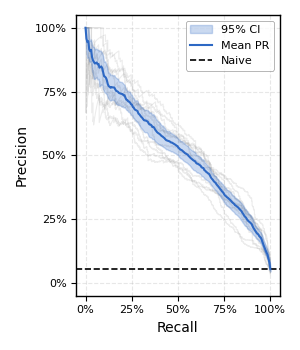

In [23]:
# Bootstrapped PR Curve

# 1. Setup Grid and Figure
recall_grid = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(3, 3.5)) 
target_df = cell_res
score_col = "confidence_score" 

# 2. Iterate and collect individual embryo curves
interp_precisions = []
for embryo_id, g in target_df.groupby("embryo_id"):
    
    y_true = (1 - g["is_correct"]).astype(int)
    y_prob = 1.0 - g[score_col]
    
    if y_true.nunique() < 2: 
        continue
    
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    
    # Interpolate to the standard grid
    interp_p = np.interp(
        recall_grid,
        recall[::-1],
        precision[::-1],
        left=precision[-1],   
        right=precision[0]    
    )
    interp_precisions.append(interp_p)
    # Plot individual raw curves in the background faintly
    ax.plot(recall, precision, color="gray", alpha=0.15, lw=0.8, zorder=1)

# 3. Bootstrap the 95% CI of the Mean
if interp_precisions:
    interp_precisions = np.vstack(interp_precisions)
    n_embryos = len(interp_precisions)
    n_bootstraps = 1000
    
    boot_means = []
    # Resample the embryo curves with replacement
    for _ in range(n_bootstraps):
        indices = np.random.choice(n_embryos, size=n_embryos, replace=True)
        sample_curves = interp_precisions[indices]
        boot_means.append(sample_curves.mean(axis=0))
        
    boot_means = np.vstack(boot_means)
    
    # Calculate the true global mean and the strict 95% Confidence Interval bounds
    mean_precision = interp_precisions.mean(axis=0)
    ci_low = np.percentile(boot_means, 2.5, axis=0)
    ci_high = np.percentile(boot_means, 97.5, axis=0)
    
    # Calculate the exact AUPRC
    mean_auprc = auc(recall_grid, mean_precision)

    # 4. Plot Mean and Bootstrapped Ribbon
    ax.fill_between(recall_grid, ci_low, ci_high, color="#2D68C4", alpha=0.25, zorder=2, label="95% CI")
    ax.plot(recall_grid, mean_precision, color="#2D68C4", lw=1.5, zorder=5, label="Mean PR")

# Global baseline frequency of errors
global_baseline = (1 - target_df["is_correct"]).mean()
ax.axhline(global_baseline, color='black', linestyle='--', lw=1.2, zorder=4, label='Naive')

# 5. Formatting & Consistency
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlabel("Recall", fontsize=med_font)
ax.set_ylabel("Precision", fontsize=med_font)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ticks = [0.0, 0.25, 0.50, 0.75, 1.0]
tick_labels = ['0%', '25%', '50%', '75%', '100%']
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=small_font)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels, fontsize=small_font)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.0)

# 6. Legend Layout
ax.legend(
    loc='upper right', 
    fontsize=small_font, 
    frameon=True, 
    edgecolor='gray'
).get_frame().set_linewidth(0.5)

plt.tight_layout()
plt.savefig('fig_outs/pr_curves.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

## Figure 1F: Normalized Confusion Matrix

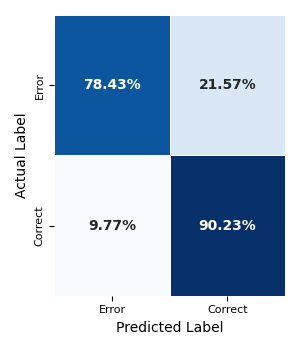

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize=(3, 3.5))
cell_res['pred_label'] = cell_res['confidence_score'] > 0.5
cm = confusion_matrix(cell_res['is_correct'], cell_res['pred_label'], normalize='true')

sns.heatmap(
    cm, annot=True, fmt='.2%', cmap='Blues', 
    cbar=False, annot_kws={"size": med_font, "weight": "bold"},
    xticklabels=['Error', 'Correct'], 
    yticklabels=['Error', 'Correct'],
    linewidths=0.5, linecolor='white', ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=med_font)
ax.set_ylabel("Actual Label", fontsize=med_font)
ax.tick_params(axis='both', labelsize=small_font)

plt.tight_layout()
plt.savefig('fig_outs/conf_mat.tiff', format='tiff', transparent=True, bbox_inches=None)
plt.show()

## Figure 1G: Confidence in Space


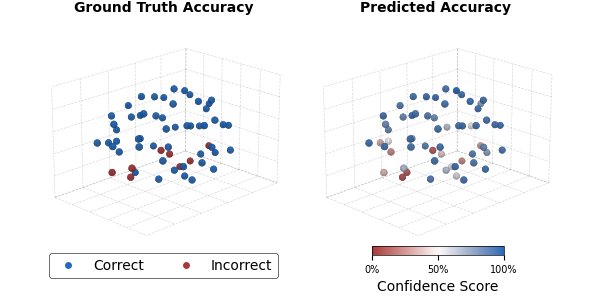

In [27]:
def get_plot_df_from_diag(diag_df, eid, t):
    frame_df = diag_df[
        (diag_df['embryo_id'] == eid) & 
        (diag_df['time_idx'] == t)
    ].copy()
    
    # Map the columns
    plot_df = pd.DataFrame({
        'x': frame_df['x_aligned'],
        'y': frame_df['y_aligned'],
        'z': frame_df['z_aligned'],
        'is_correct': frame_df['is_correct'],
        'pred_prob': frame_df['confidence_score']
    })
    
    return plot_df

def plot_spatial_diagnostic_spheres(df, eid, t):
    fig = plt.figure(figsize=(6, 3)) 
    ELEV, AZIM = 20, 45
    margin = 0.2
    x_min, x_max = df['x'].min() - margin, df['x'].max() + margin
    y_min, y_max = df['y'].min() - margin, df['y'].max() + margin
    z_min, z_max = df['z'].min() - margin, df['z'].max() + margin
    dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min

    # Palette Setup
    cmap = sns.color_palette("vlag_r", as_cmap=True)
    color_incorrect = cmap(0.0) 
    color_correct = cmap(1.0)   

    # Light Source for Brightness
    ls = LightSource(azdeg=AZIM, altdeg=ELEV + 20)

    # Sphere Mesh Generation
    radius = min(dx, dy, dz) * 0.03 
    u = np.linspace(0, 2 * np.pi, 12)
    v = np.linspace(0, np.pi, 12)
    xs = radius * np.outer(np.cos(u), np.sin(v))
    ys = radius * np.outer(np.sin(u), np.sin(v))
    zs = radius * np.outer(np.ones(np.size(u)), np.cos(v))

    def setup_stage(ax, title_text):
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max); ax.set_zlim(z_min, z_max)
        ax.set_box_aspect((dx, dy, dz)) 
        ax.view_init(elev=ELEV, azim=AZIM)
        ax.dist = 11
        grid_params = dict(color='black', linestyle='--', alpha=0.15, lw=0.5)
        ticks = 6
        for val in np.linspace(x_min, x_max, ticks):
            ax.plot([val, val], [y_min, y_max], [z_min, z_min], **grid_params)
            ax.plot([val, val], [y_min, y_min], [z_min, z_max], **grid_params)
        for val in np.linspace(y_min, y_max, ticks):
            ax.plot([x_min, x_max], [val, val], [z_min, z_min], **grid_params)
            ax.plot([x_min, x_min], [val, val], [z_min, z_max], **grid_params)
        for val in np.linspace(z_min, z_max, ticks):
            ax.plot([x_min, x_max], [y_min, y_min], [val, val], **grid_params)
            ax.plot([x_min, x_min], [y_min, y_max], [val, val], **grid_params)
        ax.set_axis_off()
        ax.set_title(title_text, fontsize=med_font, pad=-5, fontweight='bold') 

    z_lift = dz * 0.02 

    # --- PANEL 1: Ground Truth ---
    ax1 = fig.add_subplot(121, projection='3d')
    setup_stage(ax1, "Ground Truth Accuracy")
    
    for _, row in df.iterrows():
        c = color_correct if row['is_correct'] else color_incorrect
        ax1.plot_surface(xs + row['x'], ys + row['y'], zs + row['z'] + z_lift, 
                         color=c, rstride=1, cstride=1, antialiased=True, 
                         shade=True, lightsource=ls, linewidth=0)

    # --- PANEL 2: Confidence ---
    ax2 = fig.add_subplot(122, projection='3d')
    setup_stage(ax2, "Predicted Accuracy")

    for _, row in df.iterrows():
        c = cmap(row['pred_prob'])
        ax2.plot_surface(xs + row['x'], ys + row['y'], zs + row['z'] + z_lift, 
                         color=c, rstride=1, cstride=1, antialiased=True, 
                         shade=True, lightsource=ls, linewidth=0)

    # --- LEGEND & COLORBAR ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Correct',
               markerfacecolor=color_correct, markersize=6),
        Line2D([0], [0], marker='o', color='w', label='Incorrect',
               markerfacecolor=color_incorrect, markersize=6)
    ]
    leg = fig.legend(handles=legend_elements, loc='lower left', 
                     bbox_to_anchor=(0.07, 0.05), ncol=2, fontsize=med_font, 
                     frameon=True, edgecolor='black', framealpha=0.8)
    leg.get_frame().set_linewidth(0.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    cbar_ax = fig.add_axes([0.62, 0.15, 0.22, 0.03]) 
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.outline.set_edgecolor('black')
    cbar.outline.set_linewidth(0.5)
    cbar.set_label("Confidence Score", fontsize=med_font)
    cbar.set_ticks([0.0, 0.5, 1.0])
    cbar.set_ticklabels(['0%', '50%', '100%'])
    cbar.ax.tick_params(labelsize=7)
    plt.subplots_adjust(left=-0.05, right=1.05, bottom=0.12, top=0.95, wspace=-0.3)
    plt.savefig('fig_outs/spatial_conf.tiff', format='tiff', transparent=True, bbox_inches=None)
    plt.show()

eid = '200113_3'
t = 61

final_plot_df = get_plot_df_from_diag(cell_res, eid, t)

plot_spatial_diagnostic_spheres(final_plot_df, eid, t)